# Load

In [ ]:
# base
import os
from pathlib import Path
import warnings
import logging
import pickle

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io

sc.settings.verbosity = 0

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter

converter = get_converter()
%load_ext rpy2.ipython

# analysis & device specific
%matplotlib inline
CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
mpl.rcdefaults()

In [ ]:
# LOAD PROCESSED
sdata = sd.read_zarr(DATADIR / "processed" / "spatial" / "raws" / "COMBINED")
spatial_uns = pickle.load(
    open(DATADIR / "processed" / "spatial" / "raws" / "spatial_uns.pkl", "rb")
)
GROUPINGS = ["square_002um", "square_008um", "square_016um", "segmented_bins"]
SAMPLES = ["HFD-cKO-male-666-VAT", "LFD-cKO-male-780-VAT", "LFD-CTR-male-670-VAT"]
for g in GROUPINGS:
    order_obs(sdata[g], "Identifier", SAMPLES)

sdata

# Spatial Visualization (pre QC)

In [ ]:
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

f, axs = plt.subplots(1, 3, figsize=(32, 12), layout="constrained")
new_cmap = set_zero_in_cmap_to_transparent(cmap="Reds")

for i, sample in tqdm(
    enumerate(sdata["segmented_bins"].obs["Identifier"].cat.categories)
):
    sdata.pl.render_shapes(
        f"SHAPE_square_008um-{sample}",
        color="Igkc",
        cmap=new_cmap,
        # outline_width=0.1,
        # outline_color="black",
    ).pl.show(coordinate_systems=sample, ax=axs[i])

f.suptitle("Igkc expression by sample, 8um bins", size=20)

# QC Plots

In [ ]:
metrics_list = []
for binsize in GROUPINGS:
    qc = sdata[binsize].obs[["Identifier", "total_counts", "n_genes_by_counts"]]
    metrics = []
    for i, df in qc.groupby("Identifier"):
        tmp = df[["total_counts", "n_genes_by_counts"]].mean()
        tmp.name = i
        metrics.append(tmp)
    metrics = pd.concat(metrics, axis=1)
    metrics["resolution"] = binsize
    metrics_list.append(metrics)

pd.concat(metrics_list).to_csv("QC metrics by sample.csv")

In [ ]:
metrics = [
    "pct_counts_mito",
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_in_top_20_genes",
]
f = plt.figure(figsize=(8 * 4, 8 * 4), layout="constrained")
sf = f.subfigures(4, 1)

for i, binsize in enumerate(GROUPINGS):
    # get QC metrics
    sc.pp.calculate_qc_metrics(sdata[binsize], inplace=True, percent_top=[20])
    Filter_GeneGroup(sdata[binsize])

    ax = sf[i].subplots(1, 4)
    for j, met in tqdm(enumerate(metrics)):
        sns.histplot(sdata[binsize].obs[met], ax=ax[j], bins=30)
    sf[i].suptitle(f"{binsize} resolution")

f.suptitle("QC plots by resolution", size=20)

4it [10:23, 155.94s/it]
4it [00:47, 11.80s/it]
4it [00:12,  3.20s/it]
4it [00:06,  1.62s/it]


Text(0.5, 0.98, 'QC plots by resolution - split by sample')

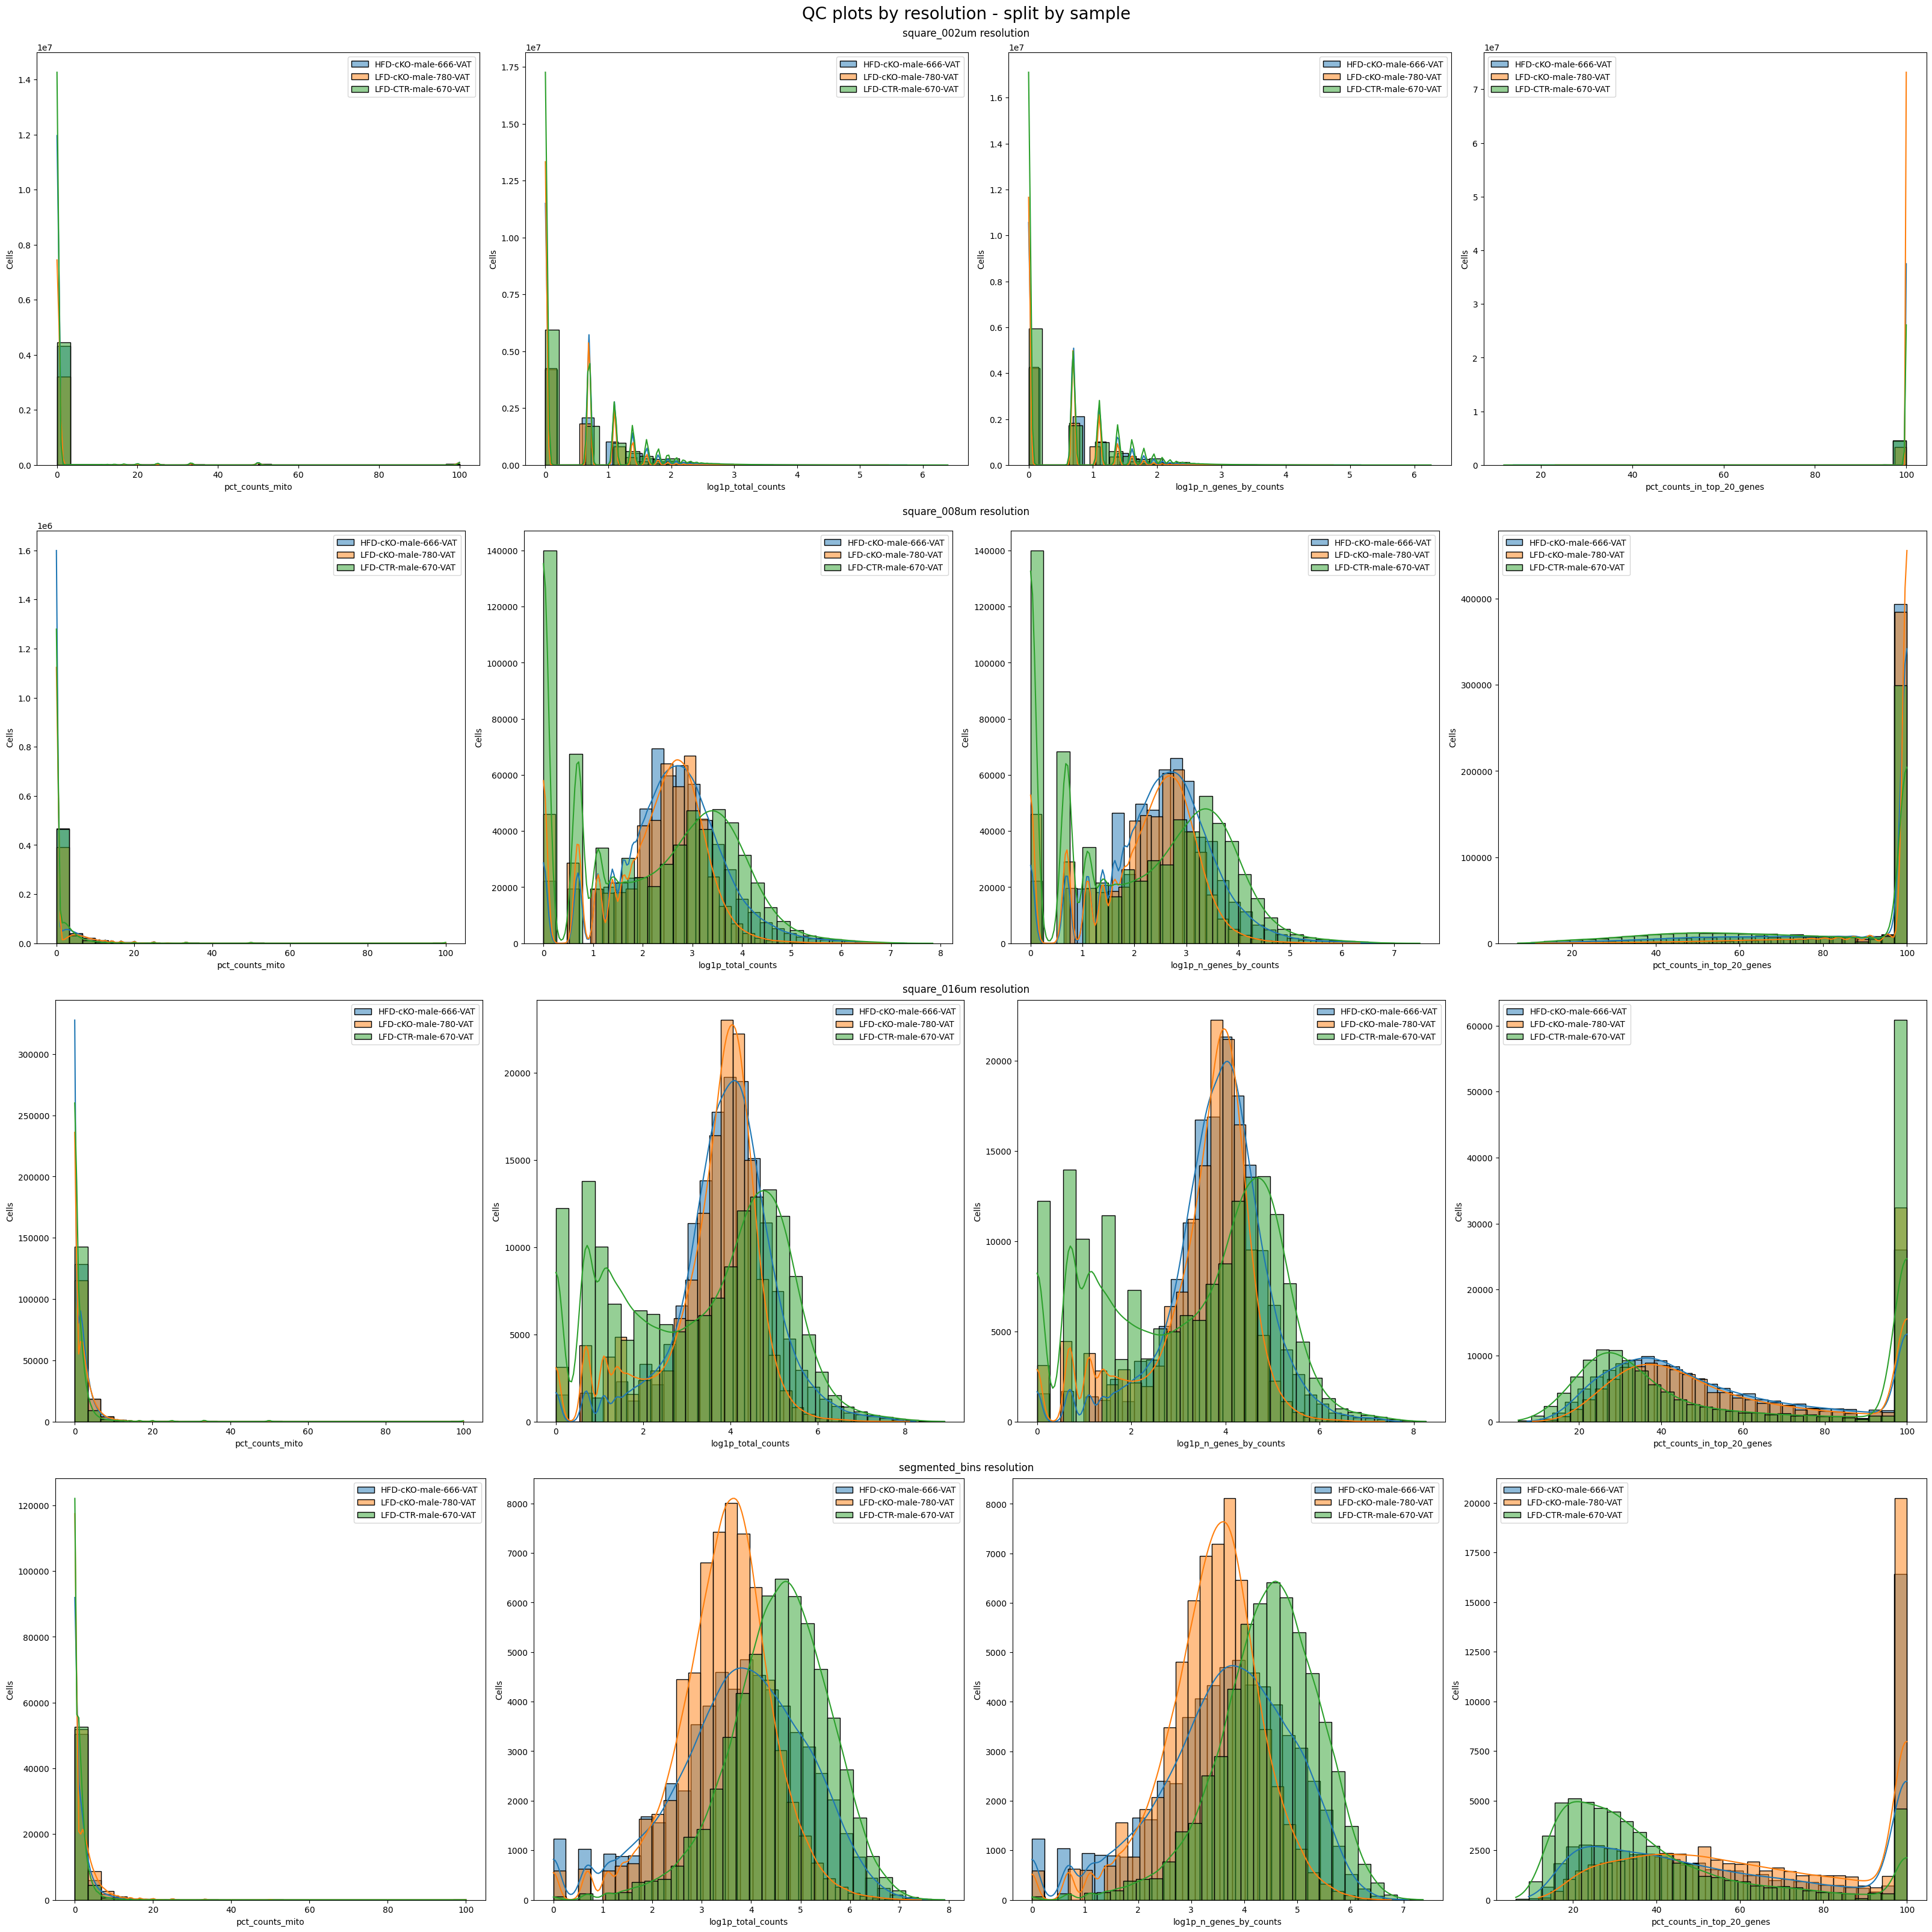

In [11]:
metrics = [
    "pct_counts_mito",
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_in_top_20_genes",
]
r, c = 4, 4
f = plt.figure(figsize=(8 * c, 8 * r), layout="constrained")
sf = f.subfigures(r, 1)

for i, binsize in enumerate(GROUPINGS):
    # get QC metrics
    sc.pp.calculate_qc_metrics(sdata[binsize], inplace=True, percent_top=[20])
    Filter_GeneGroup(sdata[binsize])

    axs = sf[i].subplots(1, c)
    for j, met in tqdm(enumerate(metrics)):
        for sample in sdata[binsize].obs["Identifier"].cat.categories:
            sns.histplot(
                sdata[binsize][sdata[binsize].obs["Identifier"] == sample].obs[met],
                ax=axs[j],
                kde=True,
                bins=30,
                label=sample,
            )
        axs[j].legend()
        axs[j].set_ylabel("Cells")
    sf[i].suptitle(f"{binsize} resolution")

f.suptitle("QC plots by resolution - split by sample", size=20)

# Clustering

### 8um bins

In [ ]:
# 8um processing
adatas = {}

barcodes = {}
savedir = REFDIR / "Spatial_Custom_Labels"
for sample in SAMPLES:
    barcodes[sample] = {}
    for csv in os.listdir(savedir / sample):
        if ".csv" in csv:
            barcodes[sample][csv] = pd.read_csv(savedir / sample / csv)
            barcodes[sample][csv]["Barcode"] = (
                barcodes[sample][csv]["Barcode"] + f"-{sample}"
            )
            barcodes[sample][csv].set_index("Barcode", inplace=True)

            if csv == "JB autocluster.csv":
                barcodes[sample][csv].columns = ["Autocluster Labels"]
            elif csv == "JB drawn.csv":
                barcodes[sample][csv].columns = ["ROI Labels"]

for sample in SAMPLES:
    adata = sdata["square_008um"][sdata["square_008um"].obs["Identifier"] == sample]

    # whole tissue barcodes
    adata.obs["in EH whole tissue"] = adata.obs_names.isin(
        barcodes[sample]["EH whole tissue.csv"].index
    )

    # autocluster barcodes
    adata.obs["in JB autocluster"] = adata.obs_names.isin(
        barcodes[sample]["JB autocluster.csv"].index
    )
    adata.obs = adata.obs.join(barcodes[sample]["JB autocluster.csv"], how="left")

    adata.obs["Autocluster Labels"] = adata.obs["Autocluster Labels"].fillna(
        "not present"
    )
    adata.obs["Autocluster Labels"] = adata.obs["Autocluster Labels"].astype(str)

    # drawn ROIs
    adata.obs["in JB drawn"] = adata.obs_names.isin(
        barcodes[sample]["JB drawn.csv"].index
    )
    adata.obs = adata.obs.join(barcodes[sample]["JB drawn.csv"], how="left")
    adata.obs["ROI Labels"] = adata.obs["ROI Labels"].fillna("not present")
    adata.obs["ROI Labels"] = adata.obs["ROI Labels"].astype(str)

    adatas[sample] = adata.copy()

In [ ]:
# Filters
runFilters = True

# QC Thresholds
filters = {"GenesPerCell": 60, "ReadsPerCell": 0, "CellsPerGene": 10, "Mito%": 15}

for sample in SAMPLES:
    adata = adatas[sample]

    # Filter on whole tissue
    removed = np.sum(adata.obs["in EH whole tissue"] == False)
    print(f"Whole Tissue Filter: {removed} ({removed / adata.shape[0] * 100:.2f}%)")
    adata = adata[adata.obs["in EH whole tissue"]]

    # Filter out annoying IgG genes
    adata = adata[:, adata.var_names.str.contains("Igh|Igk|Jchain") == 0]

    # Standard QC Filters
    Filter_QC(
        adata,
        GenePerCell=filters["GenesPerCell"],
        CountPerCell=filters["ReadsPerCell"],
        CellPerGene=filters["CellsPerGene"],
        verbose=True,
    )
    Filter_GeneGroup(
        adata,
        key="mito",
        marker="mt",
        verbose=True,
        perc_threshold=filters["Mito%"],
    )

    print(f"Remaining bins: {adata.shape[0]}\n")

    adatas[sample] = adata


adata_8um = sc.concat(adatas)
sc.pp.calculate_qc_metrics(adata_8um, inplace=True, percent_top=[20])
Filter_GeneGroup(adata_8um)
order_obs(adata_8um, "Identifier", SAMPLES)

spatial_batchFlatten(adata_8um, "Identifier")
spatial_batchMove(adata_8um, "Identifier", 1.3, 0.2)
f, ax = plt.subplots(1, 1, figsize=(18, 8), layout="constrained")
sc.pl.spatial(
    adata_8um, basis="SPATIAL", spot_size=150, color="Identifier", ax=ax, frameon=False
)

adata_8um

In [ ]:
# QC
metrics = [
    "pct_counts_mito",
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_in_top_20_genes",
]
r, c = 1, 4
f = plt.figure(figsize=(6 * c, 6 * r), layout="constrained")
axs = f.subplots(r, c)

for j, met in tqdm(enumerate(metrics)):
    for sample in SAMPLES:
        sns.histplot(
            adata_8um[adata_8um.obs["Identifier"] == sample].obs[met],
            ax=axs[j],
            kde=True,
            bins=30,
            label=sample,
        )
    axs[j].legend()
    axs[j].set_ylabel("Cells")
f.suptitle(f"8um resolution - post-filter", size=20)

In [ ]:
runProcess = False

if runProcess is True:
    np.random.seed(123)

    # preprocess
    batch_column = "Identifier"
    adata_8um.layers["counts"] = adata_8um.X.copy()
    Normalize(adata_8um)
    FindVariableGenes(adata_8um, "seurat_v3_paper", batch_column, 2000)

    # integrate
    Integrate(adata_8um, batch_column, use_var_genes=True)
    Visualize(adata_8um, localmap=True)

    # cluster
    resolutions = [0.1, 0.5, 1.0, 1.5]
    Cluster(adata_8um, resolutions=resolutions)

    adata_8um.write(
        DATADIR / "processed" / "spatial" / "analysis" / "BIN-60_10-clustered.h5ad"
    )
else:
    adata_8um = sc.read_h5ad(
        DATADIR / "processed" / "spatial" / "analysis" / "BIN-60_10-clustered.h5ad"
    )

In [ ]:
marker_genes = {
    "Fibroblast": ["Ly6a", "Pdgfra", "Pi16", "Col14a1"],
    "Adipocyte": ["Adipoq", "Lep", "Lipe", "Plin1", "Plin4"],  # , "Ankef1"],
    "B cell": ["Pax5"],  # , "Cd19", "Jchain", "Igkc"],
    "T cell": ["Cd4", "Cd3e", "Skap1"],  # "Cd8a", "Foxp3",
    "Mast cell": ["Cpa3", "Cma1", "Kit", "Tpsb2"],
    "Mono/Mac": [
        "Csf1r",
        "Trem2",
        "Adgre1",
        "C1qb",
        "Itgam",
        "Timd4",
        "Saa3",
    ],  # "Cd5l",
    "Dendritic": ["Plbd1"],  # "Flt3"
    "Endothelial": ["Pecam1", "Cdh5", "Flt1"],
    "Mesothelial": ["Msln", "Upk1b", "Upk3b", "Krt19"],
    "Stromal Mix": ["Dpp4", "Pparg", "Col3a1", "Col4a1", "Col4a2", "Col5a2", "Col6a3"],
    "Immune": ["Ptprc", "Dock2", "Arhgap15"],
    "Lymphoid": ["Ikzf3", "Ets1"],
    "Fibro+Meso": ["Pdpn", "Col1a1", "Col1a2", "Dcn", "Flrt2"],
    "DC+Mac": ["Mgl2", "Mrc1", "Lyz2"],
    "DC+Mac+Bcell": ["Cd74", "H2-Ab1"],
}

sc.pl.dotplot(
    adata_8um, var_names=marker_genes, groupby="leiden_0.1", standard_scale="var"
)
sc.pl.dotplot(
    adata_8um, var_names=marker_genes, groupby="leiden_0.5", standard_scale="var"
)
sc.pl.dotplot(
    adata_8um, var_names=marker_genes, groupby="leiden_1.0", standard_scale="var"
)
sc.pl.dotplot(
    adata_8um, var_names=marker_genes, groupby="leiden_1.5", standard_scale="var"
)

In [ ]:
resolutions = [0.1, 0.5, 1.0, 1.5]
run = True

for res in resolutions:
    cluster_key = f"leiden_{res}"
    deg_key = f"DEGs_{cluster_key}"

    if run is True:
        sc.tl.rank_genes_groups(
            adata_8um, groupby=cluster_key, key_added=deg_key, layer="normalized"
        )
    sc.pl.rank_genes_groups_dotplot(
        adata_8um,
        groupby=cluster_key,
        key=deg_key,
        n_genes=10,
        standard_scale="var",
        layer="normalized",
    )

### Segmentation Groups

In [ ]:
runFilters = True

# QC Thresholds
filters = {"GenesPerCell": 30, "ReadsPerCell": 30, "CellsPerGene": 10, "Mito%": 15}

for sample in SAMPLES:
    adata = sdata["segmented_bins"][sdata["segmented_bins"].obs["Identifier"] == sample]

    # Filter out annoying IgG genes
    adata = adata[:, adata.var_names.str.contains("Igh|Igk|Jchain") == 0]

    # Standard QC Filters
    Filter_QC(
        adata,
        GenePerCell=filters["GenesPerCell"],
        CountPerCell=filters["ReadsPerCell"],
        CellPerGene=filters["CellsPerGene"],
        verbose=True,
    )
    Filter_GeneGroup(
        adata,
        key="mito",
        marker="mt",
        verbose=True,
        perc_threshold=filters["Mito%"],
    )

    print(f"Remaining bins: {adata.shape[0]}\n")

    adatas[sample] = adata

adata_segment = sc.concat(adatas)
sc.pp.calculate_qc_metrics(adata_segment, inplace=True, percent_top=[20])
Filter_GeneGroup(adata_segment)
order_obs(adata_segment, "Identifier", SAMPLES)

In [ ]:
metrics = [
    "pct_counts_mito",
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_in_top_20_genes",
]
r, c = 1, 4
f = plt.figure(figsize=(6 * c, 6 * r), layout="constrained")
axs = f.subplots(r, c)

for j, met in tqdm(enumerate(metrics)):
    for sample in SAMPLES:
        sns.histplot(
            adata_segment[adata_segment.obs["Identifier"] == sample].obs[met],
            ax=axs[j],
            kde=True,
            bins=30,
            label=sample,
        )
    axs[j].legend()
    axs[j].set_ylabel("Cells")
f.suptitle(f"segmentation-grouped 2um bins - post-filter", size=20)

In [ ]:
adata_segment = sc.read_h5ad(
    DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered.h5ad"
)

spatial_batchFlatten(adata_segment, "Identifier")
spatial_batchMove(adata_segment, "Identifier", 1.3, 0.2)
# f, ax = plt.subplots(1, 1, figsize=(18, 8), layout="constrained")
# sc.pl.spatial(adata_segment, basis="SPATIAL", spot_size=150, color="Identifier", ax=ax, frameon=False)

In [ ]:
np.random.seed(123)

# preprocess
batch_column = "Identifier"
adata_segment.layers["counts"] = adata.X.copy()
Normalize(adata_segment)
FindVariableGenes(adata_segment, "seurat_v3_paper", batch_column, 2000)

# integrate
Integrate(adata_segment, batch_column, use_var_genes=True)
Visualize(adata_segment, localmap=True)

# cluster
resolutions = [0.1, 0.5, 1.0, 1.5]
Cluster(adata_segment, resolutions=resolutions)

In [ ]:
r, c = 2, 4
f = plt.figure(figsize=(10 * c, 6 * r), layout="constrained")
axs = f.subplots(r, c).flatten()

for i, obs in enumerate(
    [f"leiden_{res}" for res in resolutions]
    + ["log1p_total_counts", "pct_counts_in_top_20_genes", "Identifier"]
):
    sc.pl.embedding(adata_segment, "UMAP", color=obs, ax=axs[i], show=False)
axs[-1].remove()

sc.pl.embedding(adata_segment, "UMAP", color=["leiden_0.5"], legend_loc="on data")
sc.pl.violin(adata_segment, ["log1p_total_counts"], "leiden_0.5")
sc.pl.violin(adata_segment, ["log1p_total_counts"], "leiden_0.1")

In [ ]:
marker_genes = {
    "Fibroblast": ["Ly6a", "Pdgfra", "Pi16", "Col14a1"],
    "Adipocyte": ["Adipoq", "Lep", "Lipe", "Plin1", "Plin4", "Ankef1"],
    "B cell": ["Cd19", "Pax5"],  # , "Jchain", "Igkc"],
    "T cell": ["Foxp3", "Cd4", "Cd3e", "Cd8a", "Skap1"],
    "Mast cell": ["Cpa3", "Cma1", "Kit", "Tpsb2"],
    "Mono/Mac": ["Csf1r", "Trem2", "Adgre1", "C1qb", "Itgam", "Cd5l", "Timd4", "Saa3"],
    "Dendritic": ["Flt3", "Plbd1"],
    "Endothelial": ["Pecam1", "Cdh5", "Flt1"],
    "Mesothelial": ["Msln", "Upk1b", "Upk3b", "Krt19"],
    "Stromal Mix": ["Dpp4", "Pparg", "Col3a1", "Col4a1", "Col4a2", "Col5a2", "Col6a3"],
    "Immune": ["Ptprc", "Dock2", "Arhgap15"],
    "Lymphoid": ["Ikzf3", "Ets1"],
    "Fibro+Meso": ["Pdpn", "Col1a1", "Col1a2", "Dcn", "Flrt2"],
    "DC+Mac": ["Mgl2", "Mrc1", "Lyz2"],
    "DC+Mac+Bcell": ["Cd74", "H2-Ab1"],
}

sc.pl.dotplot(
    adata_segment, var_names=marker_genes, groupby="leiden_0.1", standard_scale="var"
)
sc.pl.dotplot(
    adata_segment, var_names=marker_genes, groupby="leiden_0.5", standard_scale="var"
)
sc.pl.dotplot(
    adata_segment, var_names=marker_genes, groupby="leiden_1.0", standard_scale="var"
)
sc.pl.dotplot(
    adata_segment, var_names=marker_genes, groupby="leiden_1.5", standard_scale="var"
)

In [ ]:
resolutions = [0.1, 0.5, 1.0, 1.5]
run = False

for res in resolutions:
    cluster_key = f"leiden_{res}"
    deg_key = f"DEGs_{cluster_key}"

    if run is True:
        sc.tl.rank_genes_groups(
            adata_segment, groupby=cluster_key, key_added=deg_key, layer="normalized"
        )
    sc.pl.rank_genes_groups_dotplot(
        adata_segment,
        groupby=cluster_key,
        key=deg_key,
        n_genes=10,
        standard_scale="var",
        layer="normalized",
    )

### Tangram

In [ ]:
import tangram as tg

ad_map = ad.read_zarr(DATADIR / "processed" / "spatial" / "analysis" / "tangram")

adata_sc = sc.read_h5ad(
    DATADIR
    / "processed"
    / "single cell"
    / "So2025"
    / "5_analysis"
    / "annotated-ccc.h5ad"
)

adata_st = ad.read_zarr(
    DATADIR / "processed" / "spatial" / "analysis" / "analyzed_zarr"
)

DEGlist = sc.get.rank_genes_groups_df(
    adata_sc,
    group=None,
    key="de_all",
    pval_cutoff=1e-50,
    log2fc_min=0.1,
).sort_values("pvals_adj")
DEGlist = pd.concat([df.head(200) for g, df in DEGlist.groupby("group")])
markers = DEGlist.names.unique()

tg.pp_adatas(
    adata_sc,
    adata_st,
    genes=markers,
)

In [ ]:
# Training scores
tg.plot_training_scores(ad_map, bins=30, alpha=0.5)

In [ ]:
# AUC scatterplot

DEGlist = sc.get.rank_genes_groups_df(
    adata_sc,
    group=None,
    key="de_all",
    pval_cutoff=1e-50,
    log2fc_min=0.1,
).sort_values("pvals_adj")
DEGlist = pd.concat([df.head(200) for g, df in DEGlist.groupby("group")])
markers = DEGlist.names.unique()

tg.pp_adatas(
    adata_sc,
    adata_st,
    genes=markers,
)

ad_ge = tg.project_genes(adata_map=ad_map, adata_sc=adata_sc)

df_all_genes = tg.compare_spatial_geneexp(ad_ge, adata_st, adata_sc)
tg.plot_auc(df_all_genes)

In [ ]:
# # celltype mode, vs single cell mode
# annotation_list = list(ad_map.obs['cell_type_hires'].unique())
# tg.plot_cell_annotation_sc(adata_segment, annotation_list, perc=0.02)

# Cell neighborhoods

In [ ]:
adata_segment = sc.read(
    DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered.h5ad"
)
adata_segment.obs = adata_segment.obs.loc[
    :, ~adata_segment.obs.columns.str.contains("labels|cellcharter", regex=True)
]
spatial_batchFlatten(adata_segment, "Identifier")
spatial_batchMove(adata_segment, "Identifier", 1.3, 0.2)
adata_segment.obs.loc[
    adata_segment.obs["Identifier"] == "LFD-CTR-male-670-VAT", "x"
] += 8000
adata_segment.obsm["SPATIAL"] = adata_segment.obs[["x", "y"]].to_numpy()

neighborhoods = pd.read_csv(
    DATADIR
    / "processed"
    / "spatial"
    / "analysis"
    / "final_neighborhoods"
    / "ALL_neighborhoods.csv",
    index_col=0,
)
adata_segment = adata_segment[neighborhoods.index]
for col in neighborhoods.columns:
    adata_segment.obs[col] = neighborhoods[col]

f, ax = plt.subplots(1, 1, figsize=(18, 8), layout="constrained")
sc.pl.spatial(
    adata_segment,
    basis="SPATIAL",
    spot_size=150,
    color="Identifier",
    ax=ax,
    frameon=False,
)

clear_uns(adata_segment, "colors")
clear_uns(adata_segment, "dendrogram")

adata_segment

### Banksy

In [ ]:
# Add Banksy
filename = (
    DATADIR / "processed" / "spatial" / "analysis" / "banksy" / "banksy_results.pkl"
)
batch_key = "Identifier"

with open(filename, "rb") as file:
    banksy_dict, results_df, max_num_labels = pickle.load(file)

clear_obs(adata_segment, "BANKSY")
for l in results_df["lambda_param"].unique():
    result = results_df[results_df["lambda_param"] == l].adata[0]
    for col in result.obs:
        if "label" in col:
            adata_segment.obs["BANKSY_" + col[col.find("pc") :]] = (
                result.obs[col].astype(str).astype("category")
            )

for col in adata_segment.obs.columns[adata_segment.obs.columns.str.contains("BANKSY")]:
    print(col, f"({len(adata_segment.obs[col].cat.categories)} clusters)")

del banksy_dict, results_df, max_num_labels

# r,c = len(banksy_clusters),1
# f = plt.figure(figsize=(15*c, 5*r),layout="constrained")
# axs = f.subplots(r,c)

# last = 0
# n = 0
# for col in tqdm(banksy_clusters):
#     n_clusts = len(adata_segment.obs[col].unique())
#     if n_clusts != last:
#         sc.pl.spatial(adata_segment, basis="SPATIAL", spot_size=150, color=col, ax=axs[n], frameon=False, show=False)
#         n += 1
#     last = len(adata_segment.obs[col].unique())

In [ ]:
run = True
banksy_clusters = [
    "BANKSY_pc30_nc0.50_r0.30",
    "BANKSY_pc30_nc0.20_r0.30",
    "BANKSY_pc30_nc0.20_r0.50",
    "BANKSY_pc30_nc0.50_r0.70",
]

for cluster_key in banksy_clusters:
    deg_key = f"DEGs_{cluster_key}"

    f = plt.figure(figsize=(30, 20), layout="constrained")
    sfs = f.subfigures(3, 1, height_ratios=[1.5, 1.5, 0.7])

    ax = sfs[0].subplots(1, 1)
    sc.pl.spatial(
        adata_segment,
        basis="SPATIAL",
        spot_size=150,
        color=cluster_key,
        ax=ax,
        frameon=False,
        show=False,
    )

    if run is True:
        sc.tl.rank_genes_groups(
            adata_segment, groupby=cluster_key, key_added=deg_key, layer="normalized"
        )

    axs = sfs[1].subplots(1, 1)
    axs.set_axis_off()
    sc.pl.rank_genes_groups(adata_segment, key=deg_key, ax=axs, show=False)

    ax = sfs[2].subplots(1, 1)
    sc.pl.rank_genes_groups_dotplot(
        adata_segment,
        groupby=cluster_key,
        key=deg_key,
        n_genes=10,
        standard_scale="var",
        layer="normalized",
        dendrogram=False,
        ax=ax,
        show=False,
    )

In [ ]:
for cluster_key in banksy_clusters:
    deg_key = f"DEGs_{cluster_key}"
    sc.pl.rank_genes_groups_heatmap(
        adata_segment,
        groups=adata_segment.obs[cluster_key].cat.categories,
        groupby=cluster_key,
        key=deg_key,
        n_genes=20,
        layer="normalized",
        cmap="Blues",
    )

### CellCharter

In [ ]:
# Add Cellcharter
import cellcharter as cc

top_N = 3

savedir = DATADIR / "processed" / "spatial" / "analysis" / "cellcharter"
with open(savedir / "autok.pkl", "rb") as file:
    autok = pickle.load(file)
adata_cc = sc.read_h5ad(savedir / "cellcharter.h5ad")

ax = cc.pl.autok_stability(autok, return_ax=True)
line_obj = ax.get_lines()[0]
top_stab = line_obj.get_ydata().argsort()[::-1][:top_N]
top_Ks = line_obj.get_xdata()[top_stab].astype(int)

clear_obs(adata_segment, "CELLCHARTER")
for k in top_Ks:
    adata_segment.obs[f"CELLCHARTER_k{k}"] = autok.predict(
        adata_cc, use_rep="X_cellcharter", k=k
    )
    adata_segment.obs[f"CELLCHARTER_k{k}"] = (
        adata_segment.obs[f"CELLCHARTER_k{k}"].astype(str).astype("category")
    )
adata_segment.obsm["X_cellcharter"] = adata_cc.obsm["X_cellcharter"].copy()
adata_segment.obsm["X_scVI"] = adata_cc.obsm["X_scVI"].copy()

del autok, adata_cc

In [ ]:
top_Ks = [3, 6, 11]
run = True

for k in top_Ks:
    cluster_key = f"CELLCHARTER_k{k}"
    deg_key = f"DEGs_cck{k}"

    f = plt.figure(figsize=(22, 15), layout="constrained")
    sfs = f.subfigures(3, 1, height_ratios=[1.2, 1, 0.7])

    ax = sfs[0].subplots(1, 1)
    sc.pl.spatial(
        adata_segment,
        basis="SPATIAL",
        spot_size=150,
        color=cluster_key,
        ax=ax,
        frameon=False,
        show=False,
    )

    if run is True:
        sc.tl.rank_genes_groups(
            adata_segment, groupby=cluster_key, key_added=deg_key, layer="normalized"
        )

    ax = sfs[1].subplots(1, 1)
    ax.set_axis_off()
    sc.pl.rank_genes_groups(adata_segment, key=deg_key, ax=ax, show=False)

    ax = sfs[2].subplots(1, 1)
    sc.pl.rank_genes_groups_dotplot(
        adata_segment,
        groupby=cluster_key,
        key=deg_key,
        n_genes=10,
        standard_scale="var",
        layer="normalized",
        dendrogram=False,
        ax=ax,
        show=False,
    )

In [ ]:
for k in top_Ks:
    cluster_key = f"CELLCHARTER_k{k}"
    deg_key = f"DEGs_cck{k}"
    sc.pl.rank_genes_groups_heatmap(
        adata_segment,
        groupby=cluster_key,
        key=deg_key,
        n_genes=20,
        layer="normalized",
        cmap="Blues",
    )

# Save

In [ ]:
adata_segment.write_zarr(
    DATADIR / "processed" / "spatial" / "analysis" / "analyzed_zarr"
)

In [ ]:
adata_segment = ad.read_zarr(
    DATADIR / "processed" / "spatial" / "analysis" / "analyzed_zarr"
)
adata_segment

# Spatial DEGs

# 32um bins

In [ ]:
from spatialdata import get_extent

# 8 mins to run per coordinate
extent = get_extent(sdata, coordinate_system="HFD-cKO-male-666-VAT")
extent